# VIX calibration versus subsequent S&P 500 realized volatility

This analysis began with a visual comparison between the VIX and the volatility
subsequently realized by the S&P 500.

The two series appeared to follow similar broad volatility regimes, but the VIX
frequently remained above realized volatility. This suggested a simple hypothesis:

> Perhaps much of the VIX forecast error is a persistent level offset rather than
> an inability to capture changes in the volatility regime.

The initial comparison is shown below. Each realized-volatility value is aligned
with the date of the corresponding VIX observation and contains the S&P 500 returns
from the following 21 trading sessions.

## 1. Setup and data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

HORIZON = 21          # Approximately 30 calendar days
ANNUALIZATION = 252   # Trading sessions per year
ANALYSIS_START = "2018-01-01"
TEST_START = "2023-01-01"
BIAS_WINDOW = 252


Daily closing values are downloaded for the S&P 500 (`^GSPC`) and the
CBOE Volatility Index (`^VIX`). Timezone information is removed before alignment.


In [4]:
def get_close(ticker: str, start: str = "1990-01-01") -> pd.Series:
    series = yf.Ticker(ticker).history(
        start=start,
        interval="1d",
        auto_adjust=False,
        actions=False,
    )["Close"].rename(ticker)

    series.index = pd.to_datetime(series.index).tz_localize(None)
    return series


sp500 = get_close("^GSPC").rename("SP500")
vix = get_close("^VIX").rename("VIX_expected")

market = pd.concat([sp500, vix], axis=1).dropna()
log_returns = np.log(market["SP500"]).diff()

print(f"Available period: {market.index.min().date()} to {market.index.max().date()}")
display(market.head())

Available period: 1990-01-02 to 2026-09-17


/tmp/ipykernel_24641/3656857426.py:16: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  market = pd.concat([sp500, vix], axis=1).dropna()


,SP500,VIX_expected
Date,,
1990-01-02,359.690,17.240
1990-01-03,358.760,18.190
1990-01-04,355.670,19.220
1990-01-05,352.200,20.110
1990-01-08,353.790,20.260


## 2. Forecast target

The preferred target is annualized realized volatility over the following 21 trading
sessions:

$$
RV_{t,t+21}
=\sqrt{\frac{252}{21}\sum_{i=1}^{21}r_{t+i}^{2}}\times100.
$$

It is aligned with the forecast origin: the value shown at date $t$ uses returns from
the following 21 sessions. A trailing version, known at date $t$, is retained as a
naive historical-volatility benchmark.


In [5]:
log_returns = np.log(market["SP500"]).diff()

future_realized_vol = (
    np.sqrt(
        log_returns.pow(2)
        .rolling(HORIZON)
        .mean()
        .shift(-HORIZON)
        * ANNUALIZATION
    )
    * 100
).rename("Future_realized_vol")

trailing_realized_vol = (
    np.sqrt(
        log_returns.pow(2)
        .rolling(HORIZON)
        .mean()
        * ANNUALIZATION
    )
    * 100
).rename("Trailing_realized_vol")

data = pd.concat(
    [
        market,
        log_returns.rename("SP500_log_return"),
        future_realized_vol,
        trailing_realized_vol,
    ],
    axis=1,
)


## 3. Initial visual comparison

The analysis began by comparing the VIX with the volatility subsequently realized
by the S&P 500.

Each realized-volatility value is aligned with its forecast origin: the value shown
at date $t$ contains the S&P 500 returns from the following 21 trading sessions.

The objective of this first graph is to examine whether the VIX captures similar
volatility regimes and whether a systematic difference in level is visible.

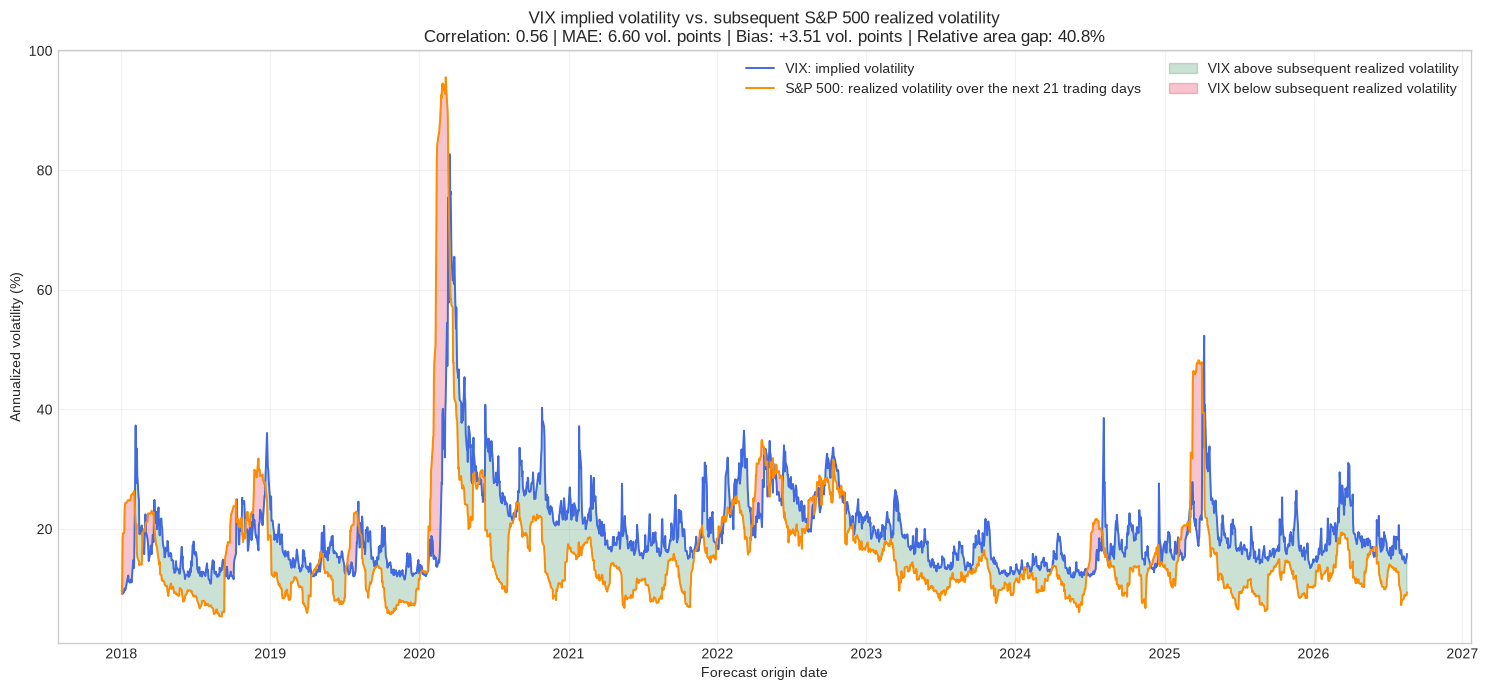

In [6]:
plot_data = (
    data.loc[
        "2018":,
        ["VIX_expected", "Future_realized_vol"],
    ]
    .dropna()
    .copy()
)

expected = plot_data["VIX_expected"]
realized = plot_data["Future_realized_vol"]

difference = expected - realized

# Evaluation metrics
correlation = expected.corr(realized)
mae = difference.abs().mean()
bias = difference.mean()

# Approximation of the relative area between the curves.
# Daily observations correspond to approximately equally spaced trading sessions.
relative_area_gap = (
    difference.abs().sum()
    / realized.abs().sum()
)

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    plot_data.index,
    expected,
    color="royalblue",
    linewidth=1.4,
    label="VIX: implied volatility",
)

ax.plot(
    plot_data.index,
    realized,
    color="darkorange",
    linewidth=1.4,
    label="S&P 500: realized volatility over the next 21 trading days",
)

# Green: VIX above subsequent realized volatility
ax.fill_between(
    plot_data.index,
    expected,
    realized,
    where=(expected >= realized),
    interpolate=True,
    color="seagreen",
    alpha=0.25,
    label="VIX above subsequent realized volatility",
)

# Red: VIX below subsequent realized volatility
ax.fill_between(
    plot_data.index,
    expected,
    realized,
    where=(expected < realized),
    interpolate=True,
    color="crimson",
    alpha=0.25,
    label="VIX below subsequent realized volatility",
)

ax.set_title(
    "VIX implied volatility vs. subsequent S&P 500 realized volatility\n"
    f"Correlation: {correlation:.2f} | "
    f"MAE: {mae:.2f} vol. points | "
    f"Bias: {bias:+.2f} vol. points | "
    f"Relative area gap: {relative_area_gap:.1%}"
)

ax.set_xlabel("Forecast origin date")
ax.set_ylabel("Annualized volatility (%)")

ax.grid(alpha=0.25)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## 4. From visual observation to a calibration model

Motivated by the apparent positive bias in the graph, a simple fixed-bias
calibration was proposed.

First, the average difference between the VIX and subsequent realized volatility
is estimated using only the training period:

$$
\widehat{b}
=
\operatorname{mean}_{\text{train}}
\left(VIX_t - RV_t\right).
$$

The calibrated forecast is then:

$$
\widehat{RV}_t
=
VIX_t - \widehat{b}.
$$

This is not a complex machine-learning model. It is a one-parameter calibration
that preserves the complete shape of the VIX series and adjusts only its level.
Equivalently, it can be interpreted as a linear regression whose slope is fixed
at one and whose intercept is learned from historical forecast errors.

The analysis then proceeds in two stages:

1. The correction is estimated with 2018–2022 data and evaluated from 2023 onward.
2. Rolling historical experiments test whether the bias and the resulting
   improvement persist across other periods and training-window lengths.

A one-feature linear regression is also included to test whether allowing both
the intercept and the VIX slope to vary adds predictive value.

This is an educational analysis, not trading advice.

## 5. Metrics and fixed calibration

- **MAE:** average absolute error in annualized volatility points.
- **Bias:** signed mean error; positive means overestimation.
- **Correlation:** similarity in co-movement, not level calibration.
- **Relative area gap:** accumulated absolute error relative to accumulated realized
  volatility.
- **$R^2$:** comparison with the test-set mean benchmark.

The last 21 training origins are purged because their targets would overlap the test
boundary. The fixed correction is learned once from 2018–2022 and remains frozen from
2023 onward.


In [7]:
def evaluate_forecast(actual: pd.Series, predicted: pd.Series) -> pd.Series:
    aligned = pd.concat(
        [actual.rename("actual"), predicted.rename("predicted")],
        axis=1,
    ).dropna()

    error = aligned["predicted"] - aligned["actual"]

    return pd.Series(
        {
            "Correlation": aligned["predicted"].corr(aligned["actual"]),
            "MAE": error.abs().mean(),
            "RMSE": np.sqrt(error.pow(2).mean()),
            "Bias": error.mean(),
            "Relative area gap": error.abs().sum() / aligned["actual"].abs().sum(),
            "R2": r2_score(aligned["actual"], aligned["predicted"]),
            "Observations": len(aligned),
        }
    )


In [8]:
def prepare_calibrations(
    frame: pd.DataFrame,
    target_col: str,
):
    calibrated = frame.loc[ANALYSIS_START:].copy()

    calibrated["Forecast_error"] = (
        calibrated["VIX_expected"]
        - calibrated[target_col]
    )

    # Usa somente erros que já seriam conhecidos na data atual.
    calibrated["Estimated_adaptive_bias"] = (
        calibrated["Forecast_error"]
        .shift(HORIZON)
        .rolling(
            BIAS_WINDOW,
            min_periods=63,
        )
        .mean()
    )

    calibrated["Adaptive_calibration"] = (
        calibrated["VIX_expected"]
        - calibrated["Estimated_adaptive_bias"]
    )

    train_candidates = (
        calibrated.loc[
            calibrated.index < TEST_START
        ]
        .dropna(subset=["Forecast_error"])
    )

    # Evita que os alvos futuros do treino invadam o teste.
    train = train_candidates.iloc[:-HORIZON].copy()

    fixed_bias = train["Forecast_error"].mean()

    test = (
        calibrated.loc[TEST_START:]
        .dropna(
            subset=[
                target_col,
                "VIX_expected",
                "Adaptive_calibration",
            ]
        )
        .copy()
    )

    test["Fixed_calibration"] = (
        test["VIX_expected"]
        - fixed_bias
    )

    return calibrated, train, test, fixed_bias

In [9]:
refined_all, refined_train, refined_test, refined_fixed_bias = (
    prepare_calibrations(data, "Future_realized_vol")
)

refined_test["Naive_trailing_vol"] = (
    refined_test["Trailing_realized_vol"]
)

benchmark_columns = {
    "Original VIX": "VIX_expected",
    "Fixed VIX calibration": "Fixed_calibration",
    "Adaptive VIX calibration": "Adaptive_calibration",
    "Naive trailing volatility": "Naive_trailing_vol",
}

benchmark_metrics = pd.concat(
    {
        model_name: evaluate_forecast(
            refined_test["Future_realized_vol"],
            refined_test[column],
        )
        for model_name, column in benchmark_columns.items()
    },
    axis=1,
)

print(f"Variance-based fixed bias: {refined_fixed_bias:.3f}")
display(benchmark_metrics.round(3))

Variance-based fixed bias: 3.155


,Original VIX,Fixed VIX calibration,Adaptive VIX calibration,Naive trailing volatility
Correlation,0.455,0.455,0.428,0.318
MAE,5.490,3.512,3.741,4.429
RMSE,6.857,5.646,5.866,7.082
Bias,3.977,0.823,0.563,0.172
Relative area gap,0.408,0.261,0.278,0.329
R2,-0.280,0.132,0.063,-0.365
Observations,909.000,909.000,909.000,909.000


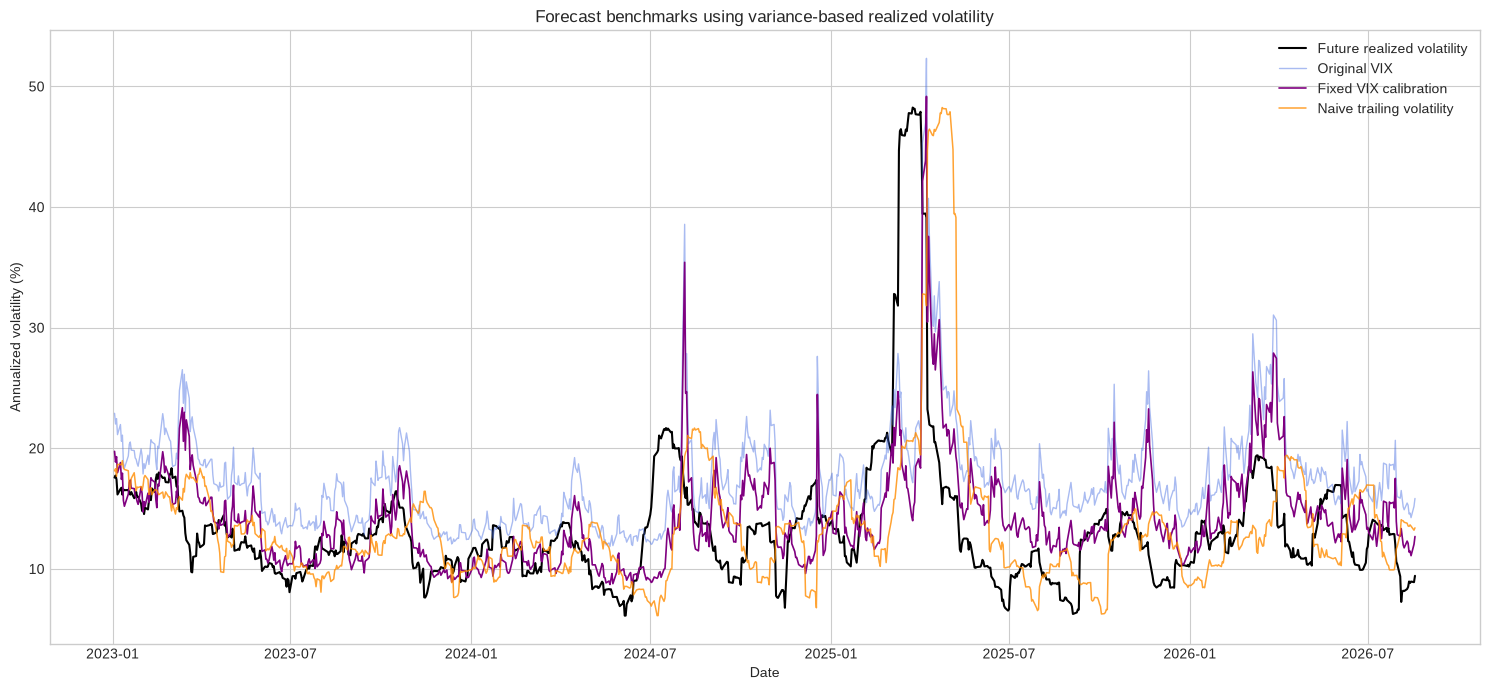

In [10]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    refined_test.index,
    refined_test["Future_realized_vol"],
    color="black",
    linewidth=1.5,
    label="Future realized volatility",
)
ax.plot(
    refined_test.index,
    refined_test["VIX_expected"],
    color="royalblue",
    alpha=0.45,
    linewidth=1.0,
    label="Original VIX",
)
ax.plot(
    refined_test.index,
    refined_test["Fixed_calibration"],
    color="purple",
    linewidth=1.2,
    label="Fixed VIX calibration",
)
ax.plot(
    refined_test.index,
    refined_test["Naive_trailing_vol"],
    color="darkorange",
    alpha=0.8,
    linewidth=1.1,
    label="Naive trailing volatility",
)

ax.set(
    title="Forecast benchmarks using variance-based realized volatility",
    xlabel="Date",
    ylabel="Annualized volatility (%)",
)
ax.legend()
plt.tight_layout()
plt.show()

### Main out-of-sample result

The fixed correction learned a bias of **3.155 volatility points** from 2018–2022.
From 2023 onward it reduced MAE from **5.490** to **3.512**, an improvement of about
**36%**. It also outperformed the naive trailing-volatility forecast, whose MAE was
**4.429**. Correlation is unchanged because subtracting a constant preserves the
shape of the VIX series.

This result motivates the historical question: is a bias near three to four points
stable across other periods, or was the 2018–2022 estimate unusually fortunate?


## 6. Historical rolling-window validation

The historical study begins in 2004 to avoid combining materially different VIX
methodologies. For every test window, the correction is estimated only from prior
data. The final 21 training origins are again purged.

Three forecasts are compared:

1. **Mean-bias calibration:** slope fixed at 1; mean error removed.
2. **Median-bias calibration:** slope fixed at 1; median error removed, directly
   targeting MAE.
3. **One-feature OLS:** both intercept and VIX slope are learned.


In [11]:
TARGET = "Future_realized_vol"

# 2004 evita misturar períodos com metodologias diferentes do VIX.
# Troque por "1990-01-01" se quiser usar absolutamente todo o histórico.
HISTORICAL_START = "2004-01-01"

historical_data = (
    data.loc[HISTORICAL_START:, ["VIX_expected", TARGET]]
    .dropna()
    .copy()
)

historical_data["VIX_error"] = (
    historical_data["VIX_expected"]
    - historical_data[TARGET]
)

print(
    historical_data.index.min().date(),
    "→",
    historical_data.index.max().date(),
)

display(historical_data.head())

2004-01-02 → 2026-08-18


,VIX_expected,Future_realized_vol,VIX_error
Date,,,
2004-01-02,18.220,10.856,7.364
2004-01-05,17.490,10.398,7.092
2004-01-06,16.730,10.407,6.323
2004-01-07,15.500,11.240,4.260
2004-01-08,15.610,11.144,4.466


In [12]:
def evaluate_historical_window(
    frame,
    test_start,
    train_years=5,
    test_years=1,
):
    test_start = pd.Timestamp(test_start)

    train_start = test_start - pd.DateOffset(years=train_years)
    test_end = test_start + pd.DateOffset(years=test_years)

    train_candidates = frame.loc[
        (frame.index >= train_start)
        & (frame.index < test_start)
    ].copy()

    # Remove as últimas 21 origens do treino porque seus alvos
    # usam retornos que avançariam para dentro do período de teste.
    if len(train_candidates) <= HORIZON:
        return None

    train = train_candidates.iloc[:-HORIZON].copy()

    test = frame.loc[
        (frame.index >= test_start)
        & (frame.index < test_end)
    ].copy()

    # Evita avaliar janelas com poucos dados.
    if len(train) < 252 or len(test) < 126:
        return None

    train_error = (
        train["VIX_expected"]
        - train[TARGET]
    )

    # Modelo 1: slope fixo em 1; aprende somente o bias.
    mean_bias = train_error.mean()

    # Modelo 2: também slope fixo em 1, mas otimiza MAE.
    median_bias = train_error.median()

    test["Mean_calibration"] = (
        test["VIX_expected"] - mean_bias
    )

    test["Median_calibration"] = (
        test["VIX_expected"] - median_bias
    )

    # Modelo 3: regressão simples.
    # Aprende tanto o intercepto quanto o slope.
    linear_model = LinearRegression()

    linear_model.fit(
        train[["VIX_expected"]],
        train[TARGET],
    )

    test["Linear_regression"] = np.clip(
        linear_model.predict(test[["VIX_expected"]]),
        a_min=0,
        a_max=None,
    )

    raw_metrics = evaluate_forecast(
        test[TARGET],
        test["VIX_expected"],
    )

    mean_metrics = evaluate_forecast(
        test[TARGET],
        test["Mean_calibration"],
    )

    median_metrics = evaluate_forecast(
        test[TARGET],
        test["Median_calibration"],
    )

    linear_metrics = evaluate_forecast(
        test[TARGET],
        test["Linear_regression"],
    )

    return {
        "Test_start": test.index.min(),
        "Test_end": test.index.max(),
        "Train_years": train_years,
        "Train_start": train.index.min(),
        "Train_end": train.index.max(),
        "Mean_bias": mean_bias,
        "Median_bias": median_bias,
        "OLS_intercept": linear_model.intercept_,
        "OLS_slope": linear_model.coef_[0],
        "Raw_MAE": raw_metrics["MAE"],
        "Mean_calibration_MAE": mean_metrics["MAE"],
        "Median_calibration_MAE": median_metrics["MAE"],
        "OLS_MAE": linear_metrics["MAE"],
        "Raw_bias": raw_metrics["Bias"],
        "Mean_calibration_bias": mean_metrics["Bias"],
        "Median_calibration_bias": median_metrics["Bias"],
        "OLS_bias": linear_metrics["Bias"],
        "Observations": len(test),
    }

In [13]:
TRAIN_LENGTHS = [2, 3, 5, 8, 10]
TEST_YEARS = 1

historical_results = []

for train_years in TRAIN_LENGTHS:
    first_possible_start = (
        historical_data.index.min()
        + pd.DateOffset(years=train_years)
    )

    last_possible_start = (
        historical_data.index.max()
        - pd.DateOffset(years=TEST_YEARS)
    )

    # Uma nova janela por mês.
    test_starts = pd.date_range(
        start=first_possible_start,
        end=last_possible_start,
        freq="MS",
    )

    for test_start in test_starts:
        result = evaluate_historical_window(
            frame=historical_data,
            test_start=test_start,
            train_years=train_years,
            test_years=TEST_YEARS,
        )

        if result is not None:
            historical_results.append(result)

historical_results = pd.DataFrame(historical_results)

historical_results["Mean_MAE_improvement"] = (
    1
    - historical_results["Mean_calibration_MAE"]
    / historical_results["Raw_MAE"]
)

historical_results["Median_MAE_improvement"] = (
    1
    - historical_results["Median_calibration_MAE"]
    / historical_results["Raw_MAE"]
)

historical_results["OLS_MAE_improvement"] = (
    1
    - historical_results["OLS_MAE"]
    / historical_results["Raw_MAE"]
)

print(f"Historical windows evaluated: {len(historical_results):,}")

display(historical_results.head())

Historical windows evaluated: 959


,Test_start,Test_end,Train_years,Train_start,Train_end,Mean_bias,Median_bias,OLS_intercept,OLS_slope,Raw_MAE,...,Median_calibration_MAE,OLS_MAE,Raw_bias,Mean_calibration_bias,Median_calibration_bias,OLS_bias,Observations,Mean_MAE_improvement,Median_MAE_improvement,OLS_MAE_improvement
0,2006-02-01,2007-01-31,2,2004-02-02,2005-12-29,3.549,3.404,5.510,0.356,3.637,...,1.666,2.191,3.356,-0.193,-0.048,0.670,251,0.546,0.542,0.398
1,2006-03-01,2007-02-28,2,2004-03-01,2006-01-27,3.476,3.389,5.536,0.352,3.790,...,2.290,2.609,2.661,-0.815,-0.729,0.015,251,0.396,0.396,0.312
2,2006-04-03,2007-03-30,2,2004-04-01,2006-03-02,3.453,3.400,5.546,0.341,3.924,...,2.388,2.615,2.790,-0.663,-0.610,-0.188,250,0.392,0.391,0.334
3,2006-05-01,2007-04-30,2,2004-05-03,2006-03-29,3.446,3.400,5.563,0.332,4.078,...,2.331,2.600,2.956,-0.490,-0.444,-0.174,251,0.430,0.428,0.363
4,2006-06-01,2007-05-31,2,2004-06-01,2006-05-01,3.226,3.258,5.053,0.375,4.076,...,2.226,2.396,3.110,-0.116,-0.149,0.087,251,0.452,0.454,0.412


## 7. Historical results

The monthly rolling experiment is a sensitivity analysis: neighboring windows
overlap heavily and should not be interpreted as independent observations. The
annual table below provides a less redundant view using five-year training windows.


In [14]:
historical_summary = (
    historical_results
    .groupby("Train_years")
    .agg(
        Windows=("Test_start", "size"),

        Median_learned_bias=("Mean_bias", "median"),
        Bias_p10=("Mean_bias", lambda x: x.quantile(0.10)),
        Bias_p90=("Mean_bias", lambda x: x.quantile(0.90)),

        Median_OLS_intercept=("OLS_intercept", "median"),
        Median_OLS_slope=("OLS_slope", "median"),

        Median_mean_gain=(
            "Mean_MAE_improvement",
            "median",
        ),
        Mean_calibration_win_rate=(
            "Mean_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),

        Median_median_gain=(
            "Median_MAE_improvement",
            "median",
        ),
        Median_calibration_win_rate=(
            "Median_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),

        Median_OLS_gain=(
            "OLS_MAE_improvement",
            "median",
        ),
        OLS_win_rate=(
            "OLS_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),
    )
)

percentage_columns = [
    "Median_mean_gain",
    "Mean_calibration_win_rate",
    "Median_median_gain",
    "Median_calibration_win_rate",
    "Median_OLS_gain",
    "OLS_win_rate",
]

historical_summary[percentage_columns] *= 100

display(historical_summary.round(3))

,Windows,Median_learned_bias,Bias_p10,Bias_p90,Median_OLS_intercept,Median_OLS_slope,Median_mean_gain,Mean_calibration_win_rate,Median_median_gain,Median_calibration_win_rate,Median_OLS_gain,OLS_win_rate
Train_years,,,,,,,,,,,,
2,235,3.352,2.079,5.057,0.792,0.795,23.772,92.766,26.670,93.617,22.648,87.234
3,223,3.317,1.860,4.972,-0.298,0.824,23.348,96.861,26.066,94.619,24.662,89.238
5,199,3.475,2.572,4.287,-0.230,0.838,26.336,100.000,27.991,97.487,27.755,98.492
8,163,3.465,3.219,3.965,-0.725,0.853,29.452,100.000,30.123,97.546,29.975,98.160
10,139,3.417,3.281,3.719,-0.574,0.843,28.428,100.000,28.347,97.842,29.091,97.842


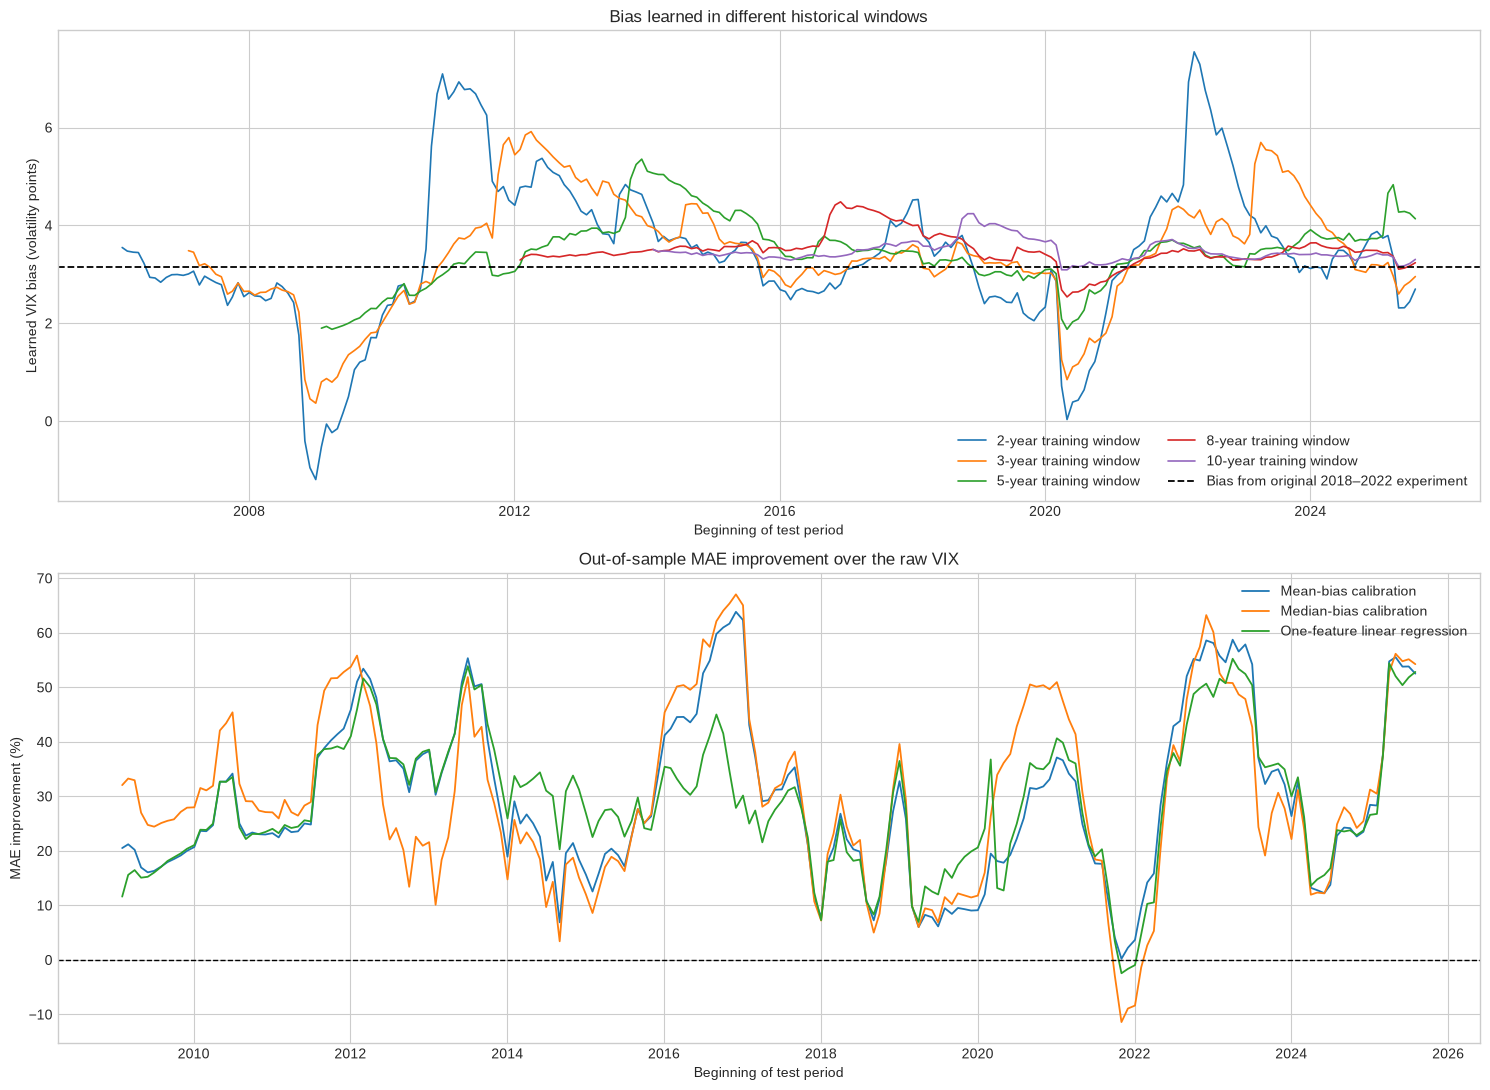

In [15]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 11),
    sharex=False,
)

# Evolução do bias aprendido
for train_years in TRAIN_LENGTHS:
    subset = historical_results[
        historical_results["Train_years"] == train_years
    ]

    axes[0].plot(
        subset["Test_start"],
        subset["Mean_bias"],
        linewidth=1.2,
        label=f"{train_years}-year training window",
    )

axes[0].axhline(
    3.155,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Bias from original 2018–2022 experiment",
)

axes[0].set(
    title="Bias learned in different historical windows",
    xlabel="Beginning of test period",
    ylabel="Learned VIX bias (volatility points)",
)

axes[0].legend(ncol=2)


# Comparação concentrada nas janelas de treino de 5 anos
five_year_results = historical_results[
    historical_results["Train_years"] == 5
]

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["Mean_MAE_improvement"],
    label="Mean-bias calibration",
    linewidth=1.3,
)

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["Median_MAE_improvement"],
    label="Median-bias calibration",
    linewidth=1.3,
)

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["OLS_MAE_improvement"],
    label="One-feature linear regression",
    linewidth=1.3,
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set(
    title="Out-of-sample MAE improvement over the raw VIX",
    xlabel="Beginning of test period",
    ylabel="MAE improvement (%)",
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
annual_results = historical_results[
    (historical_results["Train_years"] == 5)
    & (historical_results["Test_start"].dt.month == 1)
].copy()

annual_results["Test_year"] = (
    annual_results["Test_start"].dt.year
)

annual_table = annual_results[
    [
        "Test_year",
        "Mean_bias",
        "Median_bias",
        "OLS_intercept",
        "OLS_slope",
        "Raw_MAE",
        "Mean_calibration_MAE",
        "Median_calibration_MAE",
        "OLS_MAE",
        "Mean_MAE_improvement",
        "Median_MAE_improvement",
        "OLS_MAE_improvement",
    ]
].set_index("Test_year")

improvement_columns = [
    "Mean_MAE_improvement",
    "Median_MAE_improvement",
    "OLS_MAE_improvement",
]

annual_table[improvement_columns] *= 100

display(annual_table.round(3))

,Mean_bias,Median_bias,OLS_intercept,OLS_slope,Raw_MAE,Mean_calibration_MAE,Median_calibration_MAE,OLS_MAE,Mean_MAE_improvement,Median_MAE_improvement,OLS_MAE_improvement
Test_year,,,,,,,,,,,
2010,2.435,3.400,-2.023,0.981,7.965,6.315,5.736,6.287,20.713,27.991,21.071
2011,3.084,4.240,-2.186,0.962,7.404,5.682,5.400,5.623,23.255,27.068,24.045
2012,3.062,4.935,-1.275,0.931,5.249,2.840,2.427,3.096,45.900,53.756,41.026
2013,3.884,5.735,-3.541,0.987,3.805,2.346,2.983,2.337,38.337,21.604,38.575
2014,5.107,5.557,-1.451,0.835,4.230,3.430,3.606,3.132,18.928,14.767,25.955
2015,4.293,4.798,0.320,0.752,4.913,4.143,4.321,3.590,15.666,12.044,26.932
2016,3.487,4.068,1.041,0.740,5.164,3.035,2.819,3.334,41.217,45.413,35.435
2017,3.602,4.095,4.023,0.517,4.338,1.634,1.516,3.030,62.337,65.050,30.151
2018,3.471,4.157,0.712,0.711,6.193,5.714,5.746,5.742,7.748,7.225,7.288


## 6. Conclusions

The historical evidence supports the calibration result:

- Across **959 monthly rolling windows**, the median learned mean bias remained near
  **3.3–3.5 volatility points**.
- With 5-, 8-, and 10-year training windows, mean-bias calibration improved MAE in
  **100% of the monthly windows**.
- Median MAE improvement was approximately **26%–29%** for those longer training
  windows.
- In the annual five-year-window comparison, mean-bias calibration improved on the
  raw VIX in every test year from **2010 through 2025**. Annual improvement ranged
  from **3.68%** to **62.34%**.
- One-feature OLS typically learned a VIX slope near **0.8–0.85**, meaning it compressed
  VIX movements instead of merely shifting the level. It improved forecasts often,
  but was slightly less reliable than preserving a unit slope and correcting only
  the bias.

The result is therefore not that **3.155** is a universal constant. The stronger
finding is that the VIX displayed a persistent positive level premium, usually near
three to four volatility points, and a bias learned exclusively from past data
consistently improved subsequent realized-volatility forecasts.

### Limitations

- Forward 21-session targets overlap, so errors are serially dependent.
- Monthly rolling windows overlap and are used for robustness, not independent
  statistical evidence.
- Twenty-one trading sessions approximate but do not exactly equal the VIX's
  constant 30-calendar-day horizon.
- The VIX represents risk-neutral implied variance and contains a variance risk
  premium; it is not designed as an unbiased physical-world point forecast.
- Results depend on the target definition, evaluation metric, and historical period.
